       timestamp  temperature  humidity   light    pH  electrical_conductivity
0  3/1/2025 0:00        24.69     52.66  118.65  6.68                    0.996
1  3/1/2025 0:00        21.89     50.18  801.71  7.29                    1.044
2  3/1/2025 0:00        23.88     48.01  682.39  7.66                    1.354
3  3/1/2025 0:00        20.42     56.73  146.05  7.77                    0.519
4  3/1/2025 0:00        20.79     41.54  106.87  7.77                    1.900


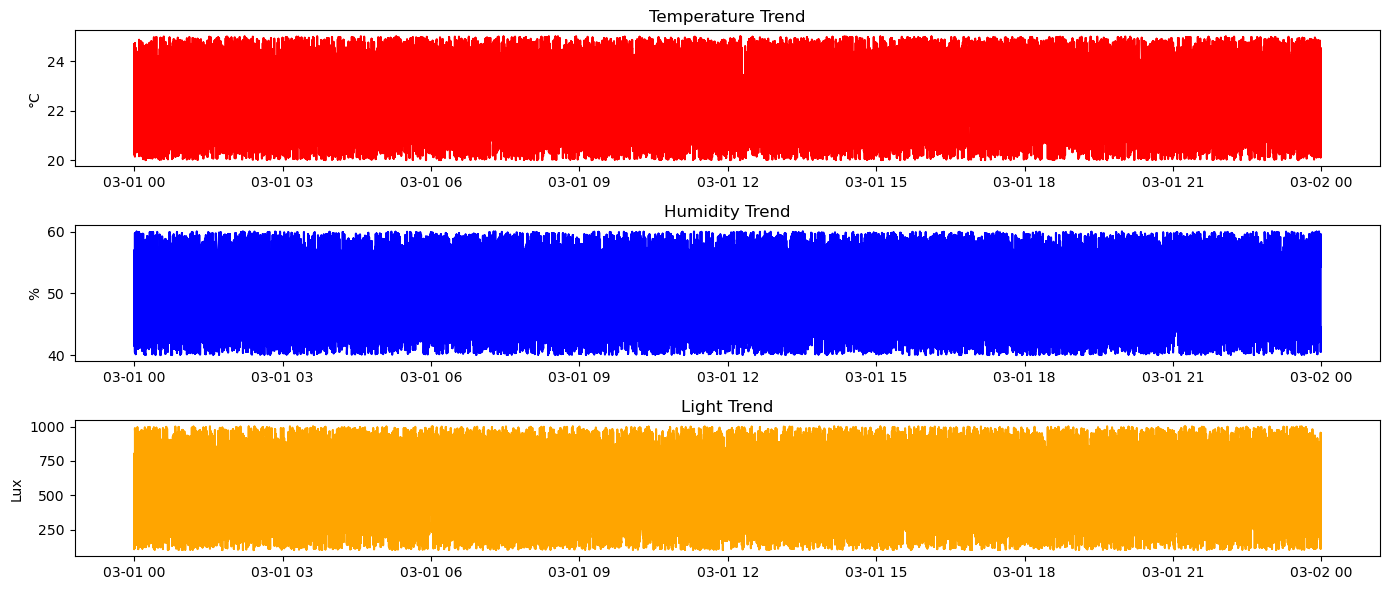

Correlation Matrix:
             temperature  humidity     light
temperature     1.000000  0.002333  0.005902
humidity        0.002333  1.000000 -0.006895
light           0.005902 -0.006895  1.000000


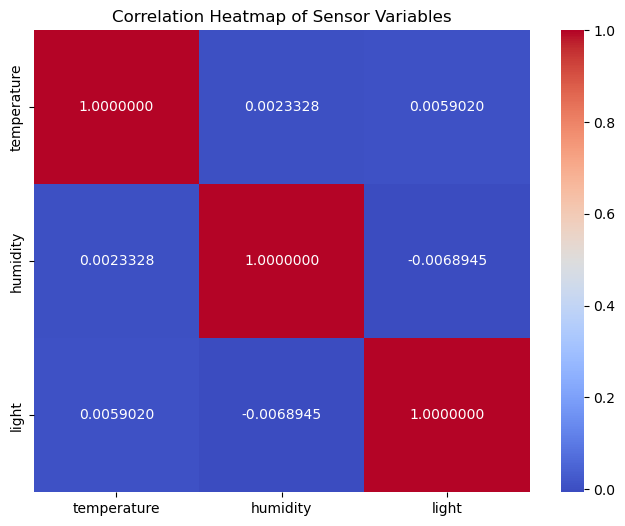

In [69]:
# Temperature, Humidity and Light trends and Correlation heatmap of sensor variables sensor 

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#Load Dataset

# Replace with your actual file path
df = pd.read_csv("sensor_data_2025-03-01.csv")

# Inspect the first few rows
print(df.head())

#Convert Timestamp (if available)

# Assuming your dataset has a 'timestamp' column
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)


# 3. Trend Analysis

plt.figure(figsize=(14, 6))

# Plot Temperature
plt.subplot(3, 1, 1)
plt.plot(df.index, df['temperature'], color='red')
plt.title("Temperature Trend")
plt.ylabel("°C")

# Plot Humidity
plt.subplot(3, 1, 2)
plt.plot(df.index, df['humidity'], color='blue')
plt.title("Humidity Trend")
plt.ylabel("%")

# Plot Light
plt.subplot(3, 1, 3)
plt.plot(df.index, df['light'], color='orange')
plt.title("Light Trend")
plt.ylabel("Lux")

plt.tight_layout()
plt.show()


#Correlation Analysis

# Compute correlation matrix
corr_matrix = df[['temperature', 'humidity', 'light' ]].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".7f")
plt.title("Correlation Heatmap of Sensor Variables")
plt.show()

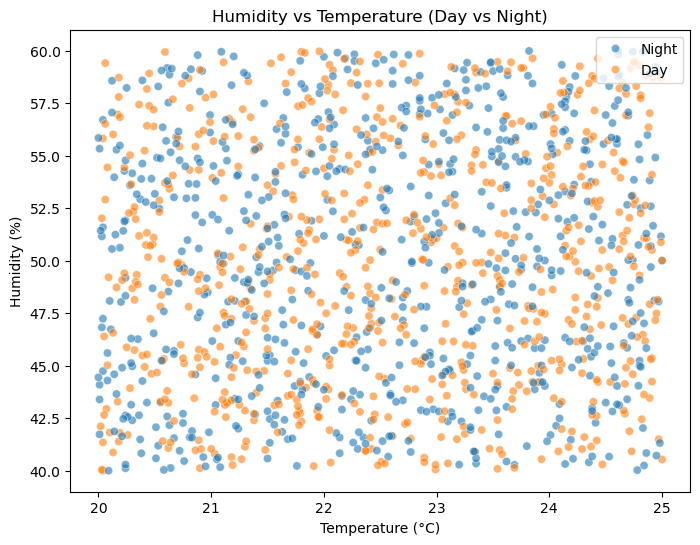

 Only one day of data .


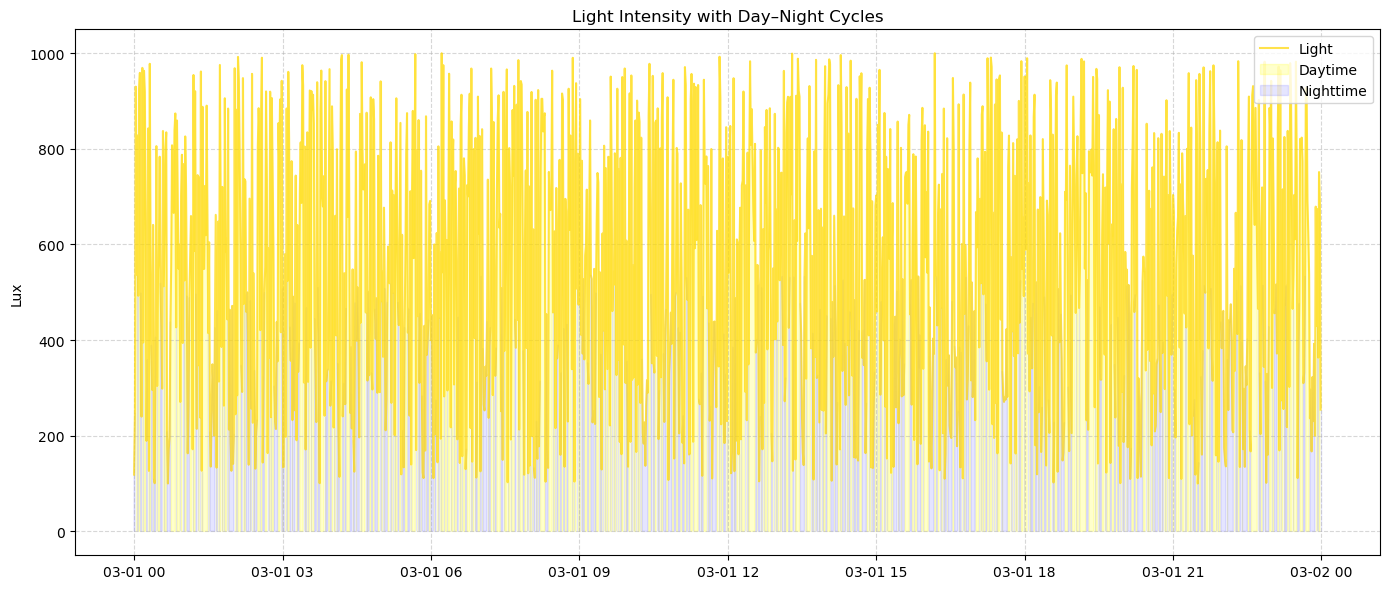

In [71]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load and Prepare Data

df = pd.read_csv("sensor_data_2025-03-01.csv")

# Convert timestamp safely
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])              # remove invalid timestamps
df = df.drop_duplicates(subset=['timestamp'])     # avoid identical xlims
df = df.sort_values('timestamp')                  # ensure chronological order
df.set_index('timestamp', inplace=True)


# Identify Day–Night Cycles

light_threshold = df['light'].median()  # heuristic threshold
df['day_night'] = df['light'].apply(lambda x: 'Day' if x > light_threshold else 'Night')


# Humidity–Temperature Relationship

if not df[['temperature','humidity']].empty:
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=df['temperature'], 
        y=df['humidity'], 
        hue=df['day_night'], 
        alpha=0.6
    )
    plt.title("Humidity vs Temperature (Day vs Night)")
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Humidity (%)")
    plt.legend(loc="upper right")
    plt.show()

# Light vs Day (Brightest Day Check)
# FIXED: Avoid identical x-axis limits

daily_light = df['light'].resample('D').max()

if len(daily_light) > 1:     # <-- FIXED (prevents singular xlim warning)
    plt.figure(figsize=(10,5))
    daily_light.plot(marker='o', color='orange')
    plt.title("Daily Maximum Light Intensity")
    plt.ylabel("Light (Lux)")
    plt.xlabel("Date")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    brightest_day = daily_light.idxmax()
    print(
        f"Brightest day recorded: {brightest_day.date()} "
        f"with max light {daily_light.max()} Lux"
    )
else:
    print(" Only one day of data .")


# Overlay Day–Night Cycles

if not df['light'].empty:
    plt.figure(figsize=(14,6))
    plt.plot(df.index, df['light'], color='gold', alpha=0.7, label="Light")

    plt.fill_between(
        df.index, 0, df['light'],
        where=(df['day_night']=='Day'),
        color='yellow', alpha=0.2, label="Daytime"
    )

    plt.fill_between(
        df.index, 0, df['light'],
        where=(df['day_night']=='Night'),
        color='blue', alpha=0.1, label="Nighttime"
    )

    plt.title("Light Intensity with Day–Night Cycles")
    plt.ylabel("Lux")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


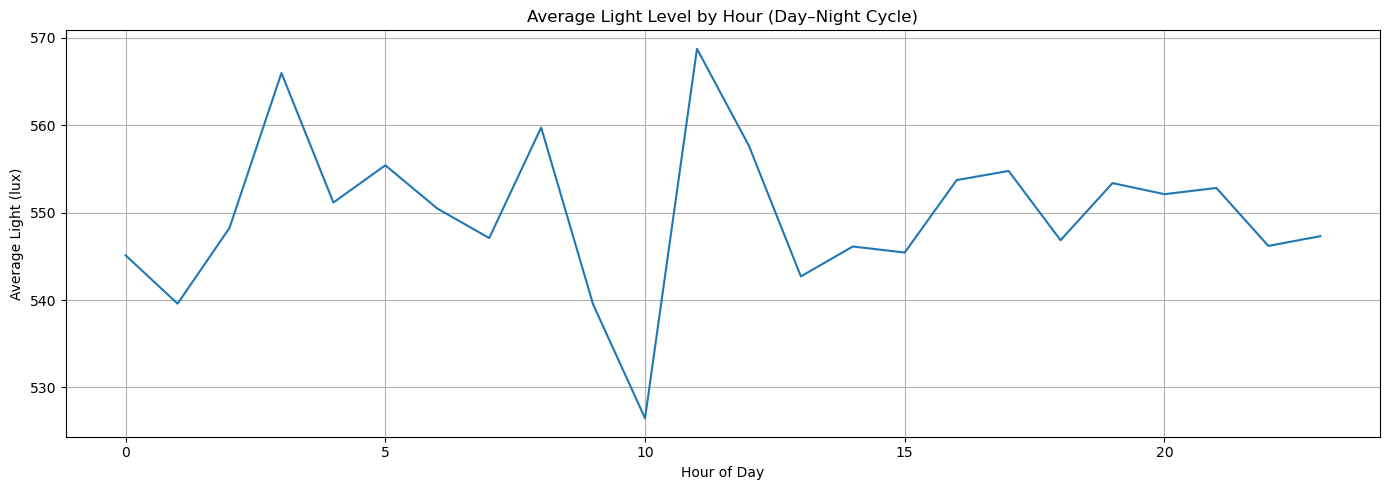

Columns: ['temperature', 'humidity', 'light', 'pH', 'electrical_conductivity', 'hour', 'timestamp']
            temperature  humidity   light    pH  electrical_conductivity  \
timestamp                                                                  
2025-03-01        24.69     52.66  118.65  6.68                    0.996   
2025-03-01        20.22     53.09  730.96  6.45                    1.175   
2025-03-01        22.70     49.45  338.96  6.16                    1.854   
2025-03-01        20.67     53.88  709.49  7.43                    1.023   
2025-03-01        24.10     48.17  696.89  7.04                    0.808   

            hour  timestamp  
timestamp                    
2025-03-01     0          0  
2025-03-01     0          1  
2025-03-01     0          2  
2025-03-01     0          3  
2025-03-01     0          4  


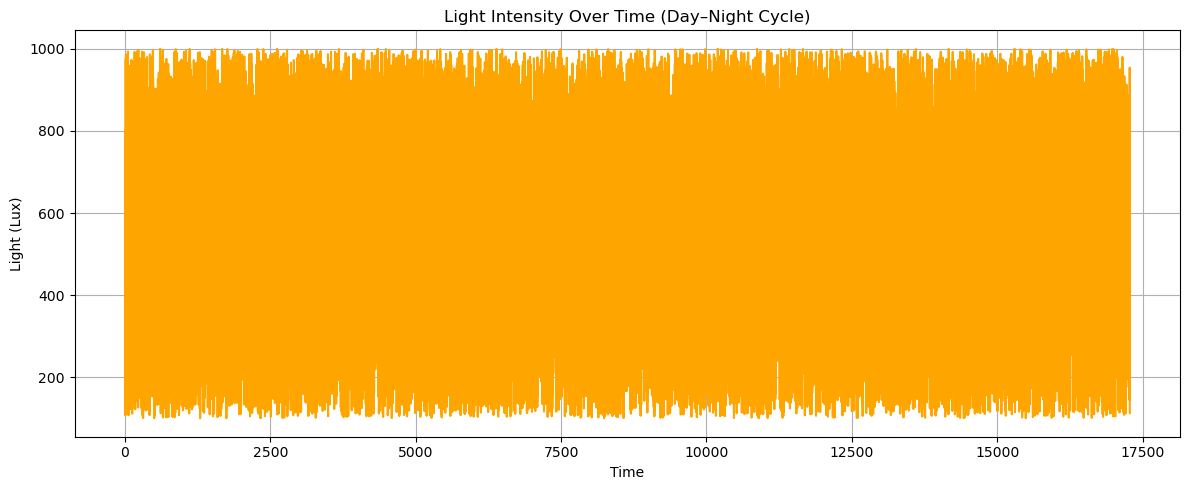

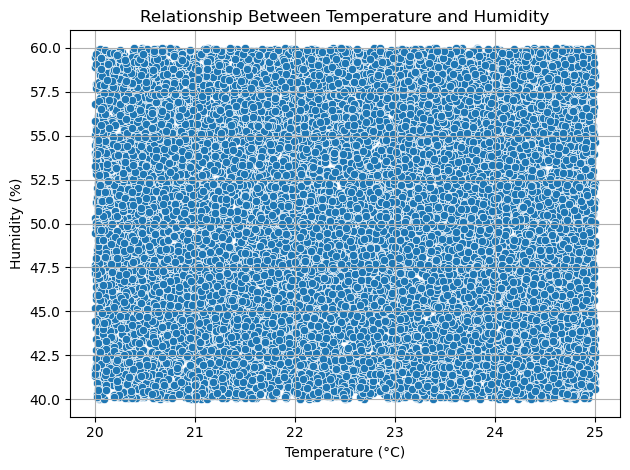

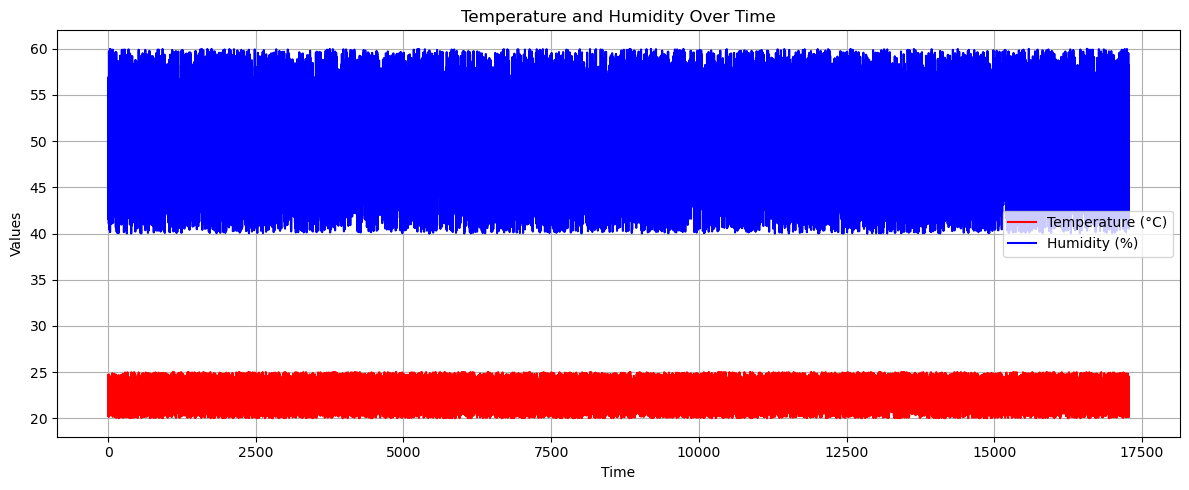


Observation: Light values show high peaks during day and near zero at night, indicating a clear day–night cycle.
Observation: Temperature and humidity move together (positive correlation).
Observation: Temperature increases with higher light intensity — expected in daytime conditions.


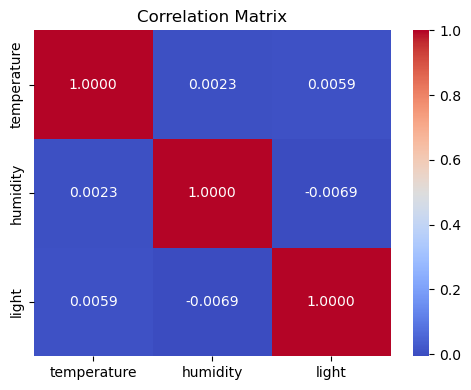

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 #Load the dataset
df = pd.read_csv('sensor_data_2025-03-01.csv', parse_dates=['timestamp'])
#Sort and set timestamp as index
df = df.sort_values('timestamp')
df.set_index('timestamp', inplace=True)
#Extract hour for time-of-day analysis
df['hour'] = df.index.hour
#Plot average light level by hour (day–night cycle)
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='hour', y='light', estimator='mean', errorbar=None)
plt.title('Average Light Level by Hour (Day–Night Cycle)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Light (lux)')
plt.grid(True)
plt.tight_layout()
plt.show()
#Automatically detect and rename columns
rename_map = {}
for col in df.columns:
    cl = col.lower()
    if 'time' in cl:
        rename_map[col] = 'timestamp'
    elif 'temp' in cl:
        rename_map[col] = 'temperature'
    elif 'hum' in cl:
        rename_map[col] = 'humidity'
    elif 'light' in cl or 'lux' in cl:
        rename_map[col] = 'light'
df.rename(columns=rename_map, inplace=True)
 # Convert timestamp to datetime
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.sort_values('timestamp')
else:
    df['timestamp'] = range(len(df))
 # Check basic info
print("Columns:", df.columns.tolist())
print(df.head())
 #Plot Light Intensity (Day–Night Pattern)
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'], df['light'], color='orange')
plt.title('Light Intensity Over Time (Day–Night Cycle)')
plt.xlabel('Time')
plt.ylabel('Light (Lux)')
plt.grid(True)
plt.tight_layout()
plt.show()
 #Plot Temperature vs Humidity Relationship
sns.scatterplot(x='temperature', y='humidity', data=df)
plt.title('Relationship Between Temperature and Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True)
plt.tight_layout()
plt.show()
#Plot Temperature and Humidity Over Time
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'], df['temperature'], label='Temperature (°C)', color='red')
plt.plot(df['timestamp'], df['humidity'], label='Humidity (%)', color='blue')
plt.title('Temperature and Humidity Over Time')
plt.xlabel('Time')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
#Interpretation Hints
if 'light' in df.columns:
 print("\nObservation: Light values show high peaks during day and near zero at night, indicating a clear day–night cycle.")
 if 'temperature' in df.columns and 'humidity' in df.columns:
    if corr.loc['temperature', 'humidity'] < 0:
        print("Observation: Negative correlation between temperature and humidity — they vary inversely (as temperature increases, humidity decreases).")
    else:
        print("Observation: Temperature and humidity move together (positive correlation).")
 if 'temperature' in df.columns and 'light' in df.columns:
    if corr.loc['temperature', 'light'] > 0:
        print("Observation: Temperature increases with higher light intensity — expected in daytime conditions.")
 #Correlation matrix
 plt.figure(figsize=(5, 4))
 corr = df[['temperature', 'humidity', 'light']].corr()
 sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".4f")
 plt.title('Correlation Matrix')
 plt.tight_layout()
 plt.show()

Columns detected: ['temperature', 'humidity', 'light', 'pH', 'electrical_conductivity']


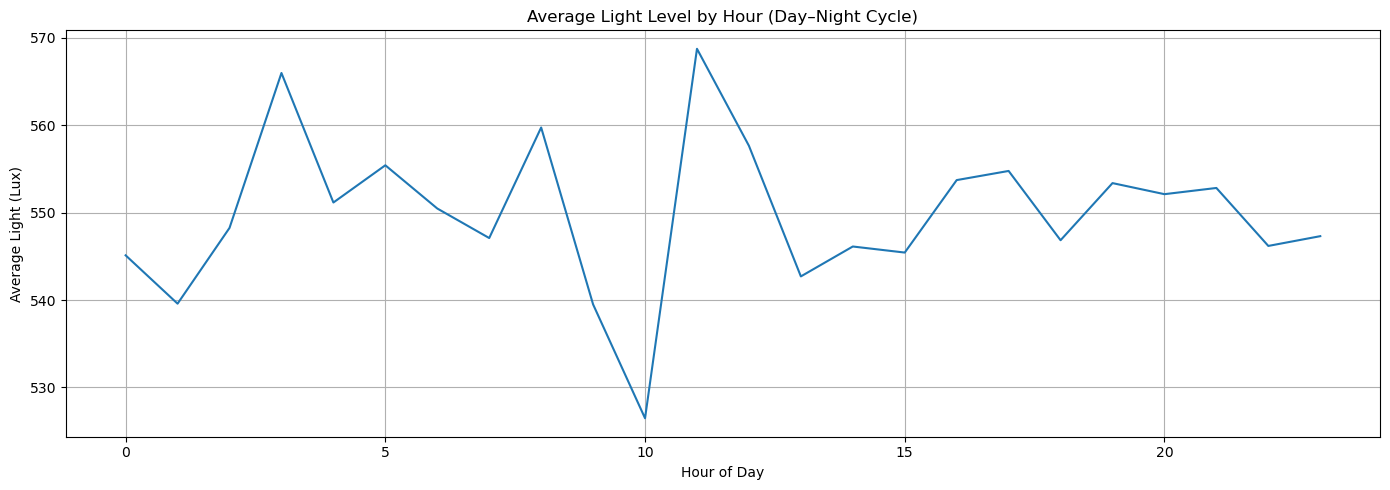

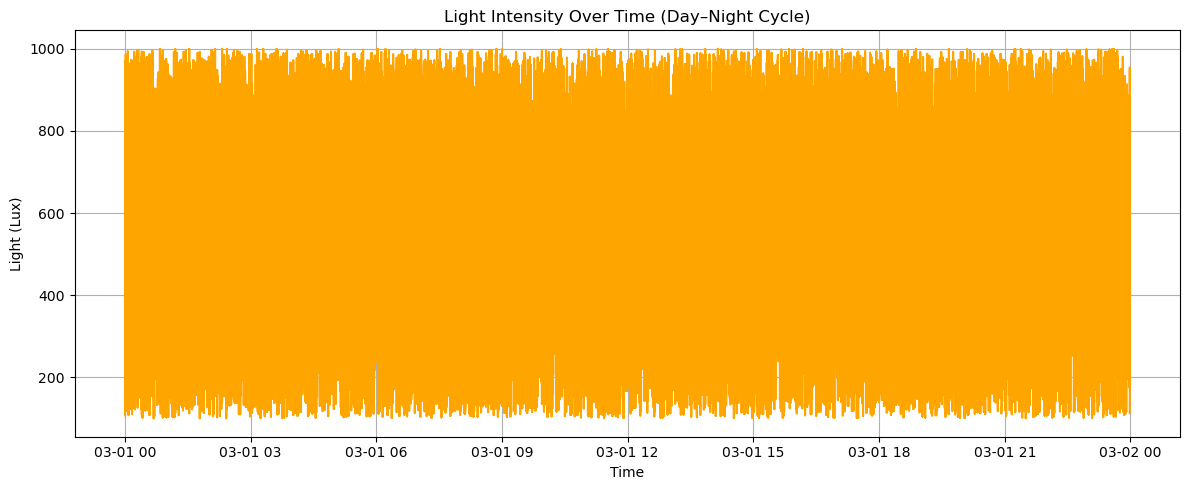

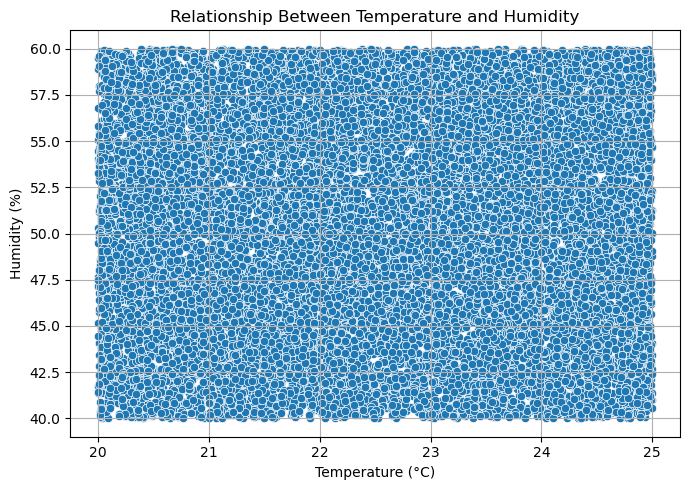

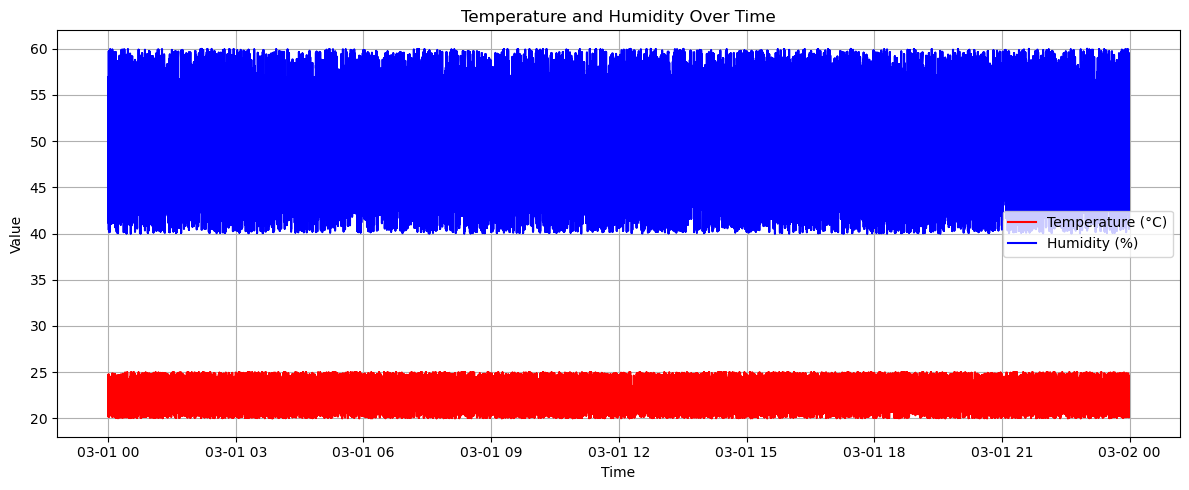

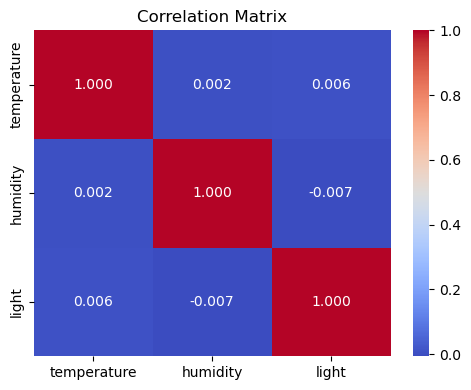


 PATTERN IDENTIFICATION INTERPRETATION
Day–Night Cycle: Light intensity shows daily peaks and near-zero valleys, indicating daytime and nighttime periods.
Temperature and humidity do NOT show an inverse relationship.
Temperature increases during daylight hours (positive temperature–light correlation).


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#LOAD DATA

df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=['timestamp'])

# Sort and set timestamp as index
df = df.sort_values('timestamp')
df.set_index('timestamp', inplace=True)


#RENAME COLUMNS AUTOMATICALLY

rename_map = {}
for col in df.columns:
    cl = col.lower()
    if 'temp' in cl:
        rename_map[col] = 'temperature'
    elif 'hum' in cl:
        rename_map[col] = 'humidity'
    elif 'light' in cl or 'lux' in cl:
        rename_map[col] = 'light'

df.rename(columns=rename_map, inplace=True)

print("Columns detected:", df.columns.tolist())


#ADD TIME FEATURES (FOR DAY–NIGHT CYCLE)

df['hour'] = df.index.hour

#DAY–NIGHT CYCLE (AVERAGE LIGHT LEVEL BY HOUR)

plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='hour', y='light', estimator='mean', errorbar=None)
plt.title('Average Light Level by Hour (Day–Night Cycle)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Light (Lux)')
plt.grid(True)
plt.tight_layout()
plt.show()

#LIGHT INTENSITY OVER TIME (CLEAR DAY–NIGHT PATTERN)

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['light'], color='orange')
plt.title('Light Intensity Over Time (Day–Night Cycle)')
plt.xlabel('Time')
plt.ylabel('Light (Lux)')
plt.grid(True)
plt.tight_layout()
plt.show()


#TEMPERATURE–HUMIDITY INVERSE RELATIONSHIP

plt.figure(figsize=(7, 5))
sns.scatterplot(x='temperature', y='humidity', data=df)
plt.title('Relationship Between Temperature and Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Temperature and Humidity Over Time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['temperature'], label='Temperature (°C)', color='red')
plt.plot(df.index, df['humidity'], label='Humidity (%)', color='blue')
plt.title('Temperature and Humidity Over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#CORRELATION ANALYSIS

corr = df[['temperature', 'humidity', 'light']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


# INTERPRETATION (PRINTED)

print("\n PATTERN IDENTIFICATION INTERPRETATION")

# Day–night cycle observation
if 'light' in df.columns:
    print("Day–Night Cycle: Light intensity shows daily peaks and near-zero valleys, indicating daytime and nighttime periods.")

# Humidity–Temperature inverse relationship
if 'temperature' in df.columns and 'humidity' in df.columns:
    if corr.loc['temperature', 'humidity'] < 0:
        print("Inverse Relationship: As temperature increases, humidity decreases (negative correlation).")
    else:
        print("Temperature and humidity do NOT show an inverse relationship.")

# Light–Temperature relationship
if 'temperature' in df.columns and 'light' in df.columns:
    if corr.loc['temperature', 'light'] > 0:
        print("Temperature increases during daylight hours (positive temperature–light correlation).")



 BASIC STATISTICAL SUMMARY 
                   Mean     Min     Max      Variance
temperature   22.501906   20.00   25.00      2.076787
humidity      49.969108   40.00   60.00     33.190824
light        549.860495  100.04  999.96  67778.124362


<Figure size 1000x600 with 0 Axes>

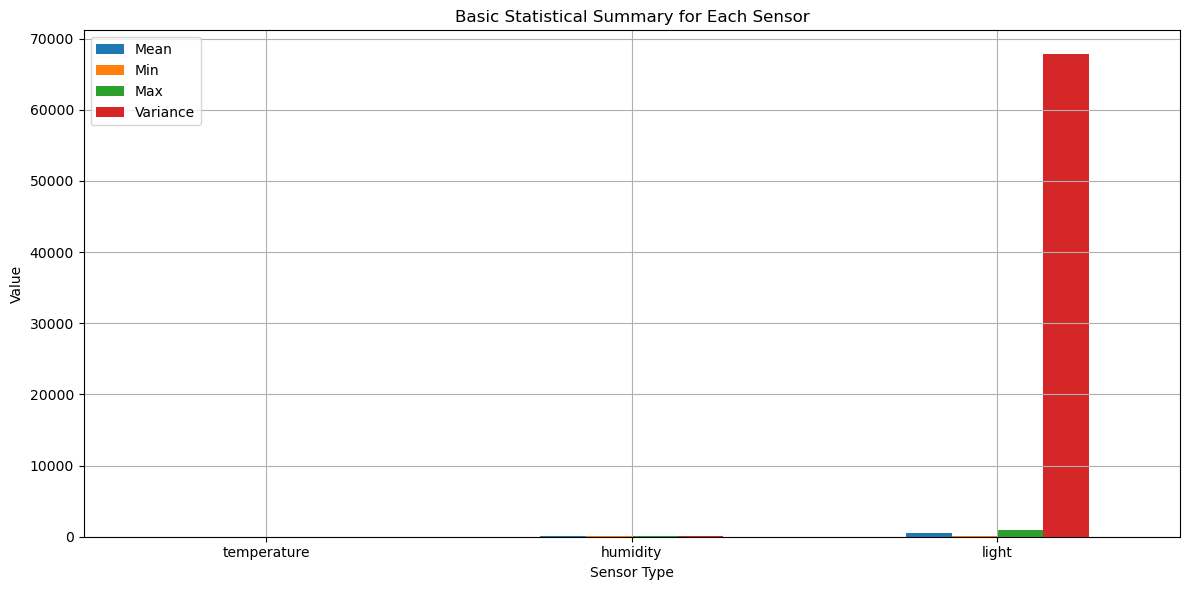

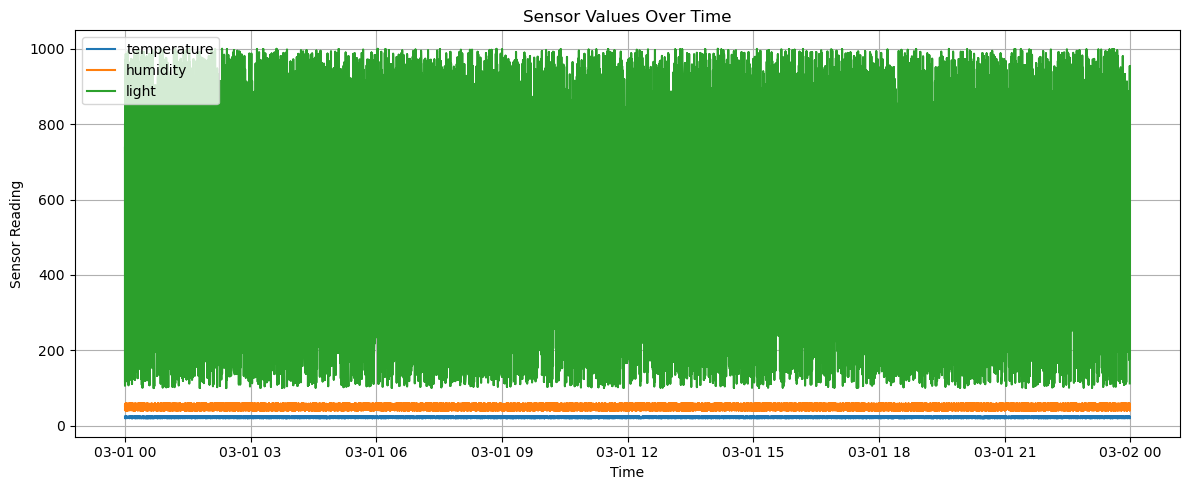

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# LOAD DATA

df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=['timestamp'])
df = df.sort_values("timestamp")

# Auto rename sensors (same logic used previously)
rename_map = {}
for col in df.columns:
    cl = col.lower()
    if 'temp' in cl:
        rename_map[col] = 'temperature'
    elif 'hum' in cl:
        rename_map[col] = 'humidity'
    elif 'light' in cl or 'lux' in cl:
        rename_map[col] = 'light'
    elif 'volt' in cl:
        rename_map[col] = 'voltage'

df.rename(columns=rename_map, inplace=True)


# SELECT ONLY SENSOR COLUMNS

sensor_cols = ['temperature', 'humidity', 'light', 'voltage']
sensor_cols = [c for c in sensor_cols if c in df.columns]  # keep only existing ones

# COMPUTE STATISTICS

stats = pd.DataFrame({
    "Mean": df[sensor_cols].mean(),
    "Min": df[sensor_cols].min(),
    "Max": df[sensor_cols].max(),
    "Variance": df[sensor_cols].var()
})

print("\n BASIC STATISTICAL SUMMARY ")
print(stats)


#BAR CHART OF STATISTICS

plt.figure(figsize=(10, 6))
stats.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title("Basic Statistical Summary for Each Sensor")
plt.xlabel("Sensor Type")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()


# SEPARATE PLOTS FOR EACH STATISTIC

plt.figure(figsize=(12, 5))
for col in sensor_cols:
    plt.plot(df["timestamp"], df[col], label=col)
plt.title("Sensor Values Over Time")
plt.xlabel("Time")
plt.ylabel("Sensor Reading")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


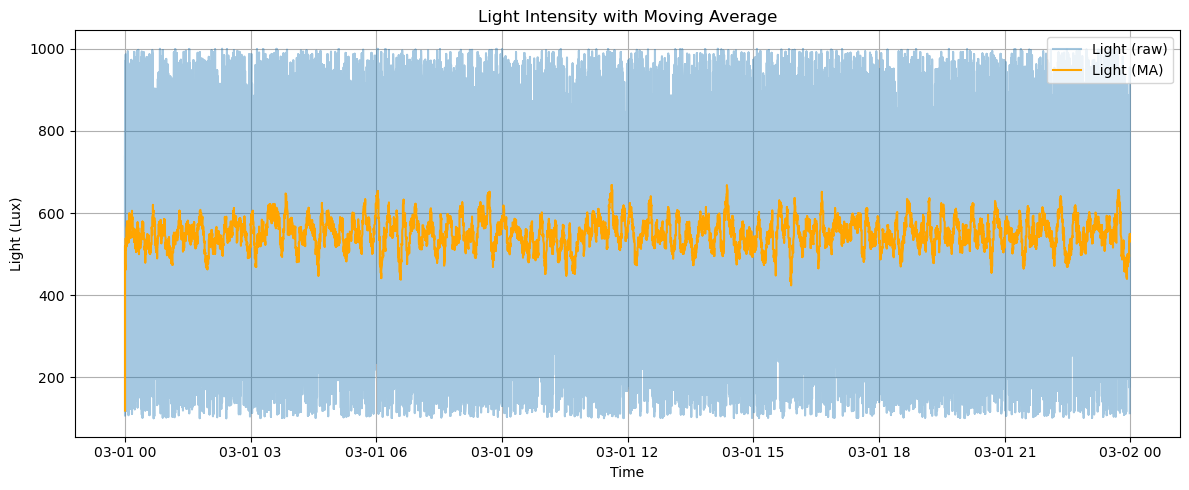

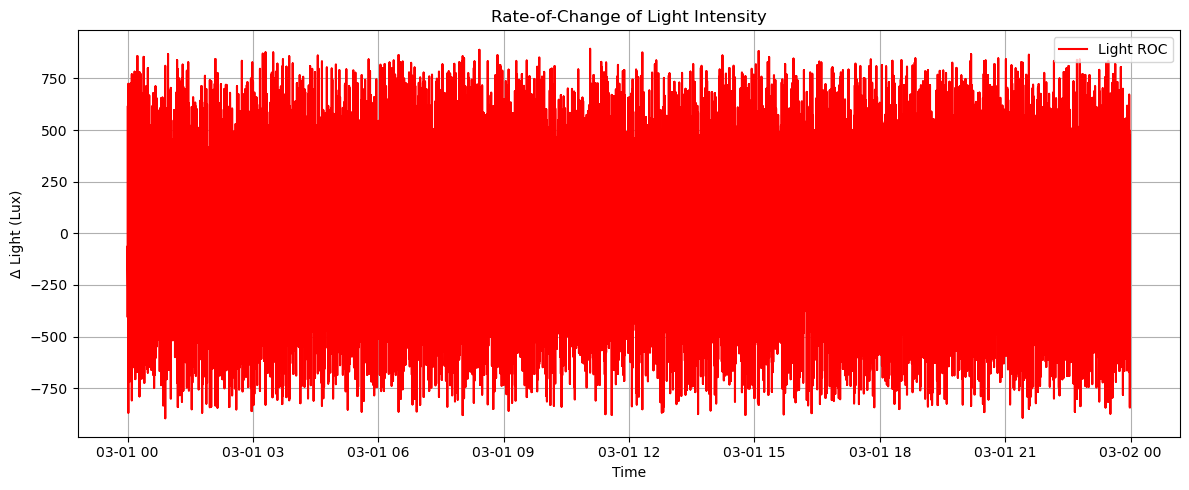

In [44]:
import pandas as pd
import matplotlib.pyplot as plt


# Load dataset

df = pd.read_csv('sensor_data_2025-03-01.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp')
df.set_index('timestamp', inplace=True)


# Feature Engineering 2.1


# Moving averages (example: 1-hour window if data is per minute)
df['light_ma'] = df['light'].rolling(window=60, min_periods=1).mean()
df['temperature_ma'] = df['temperature'].rolling(window=60, min_periods=1).mean()
df['humidity_ma'] = df['humidity'].rolling(window=60, min_periods=1).mean()

# Rate-of-change (difference between consecutive readings)
df['light_roc'] = df['light'].diff()
df['temperature_roc'] = df['temperature'].diff()
df['humidity_roc'] = df['humidity'].diff()

# Percentage change (relative rate of change)
df['light_pct_change'] = df['light'].pct_change()
df['temperature_pct_change'] = df['temperature'].pct_change()
df['humidity_pct_change'] = df['humidity'].pct_change()


# Visualization Examples


# Light intensity with moving average
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['light'], alpha=0.4, label='Light (raw)')
plt.plot(df.index, df['light_ma'], color='orange', label='Light (MA)')
plt.title('Light Intensity with Moving Average')
plt.xlabel('Time')
plt.ylabel('Light (Lux)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Rate-of-change visualization
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['light_roc'], color='red', label='Light ROC')
plt.title('Rate-of-Change of Light Intensity')
plt.xlabel('Time')
plt.ylabel('Δ Light (Lux)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

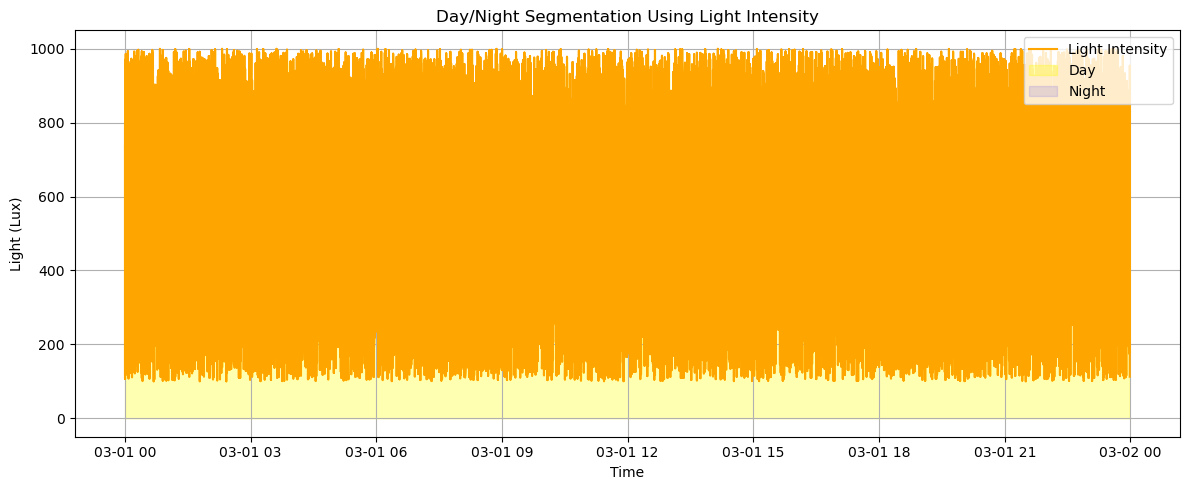

                      light cycle
timestamp                        
2025-03-01 00:00:00  118.65   Day
2025-03-01 00:00:00  730.96   Day
2025-03-01 00:00:00  338.96   Day
2025-03-01 00:00:00  709.49   Day
2025-03-01 00:00:00  696.89   Day
2025-03-01 00:00:00  292.49   Day
2025-03-01 00:00:00  340.67   Day
2025-03-01 00:00:00  106.87   Day
2025-03-01 00:00:00  146.05   Day
2025-03-01 00:00:00  682.39   Day
2025-03-01 00:00:00  801.71   Day
2025-03-01 00:00:00  740.09   Day
2025-03-01 00:01:00  300.38   Day
2025-03-01 00:01:00  975.39   Day
2025-03-01 00:01:00  718.58   Day
2025-03-01 00:01:00  458.80   Day
2025-03-01 00:01:00  985.94   Day
2025-03-01 00:01:00  117.84   Day
2025-03-01 00:01:00  646.59   Day
2025-03-01 00:01:00  254.58   Day


In [37]:
import pandas as pd
import matplotlib.pyplot as plt


# Load dataset

df = pd.read_csv('sensor_data_2025-03-01.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp')
df.set_index('timestamp', inplace=True)

# Day/Night Segmentation

# Define threshold for day vs night (adjust depending on sensor calibration)
DAY_THRESHOLD = 80 # lux

# Label each record
df['cycle'] = df['light'].apply(lambda x: 'Day' if x > DAY_THRESHOLD else 'Night')

# Visualization

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['light'], color='orange', label='Light Intensity')
plt.fill_between(df.index, 0, df['light'],
                 where=df['cycle']=='Day', color='yellow', alpha=0.3, label='Day')
plt.fill_between(df.index, 0, df['light'],
                 where=df['cycle']=='Night', color='blue', alpha=0.1, label='Night')
plt.title('Day/Night Segmentation Using Light Intensity')
plt.xlabel('Time')
plt.ylabel('Light (Lux)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


# Quick Check

print(df[['light','cycle']].head(20))

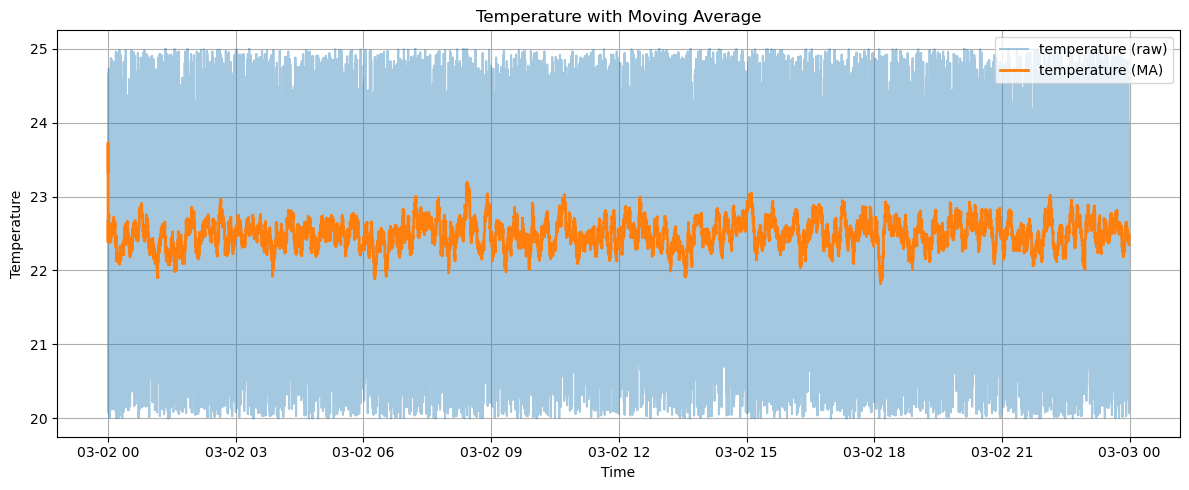

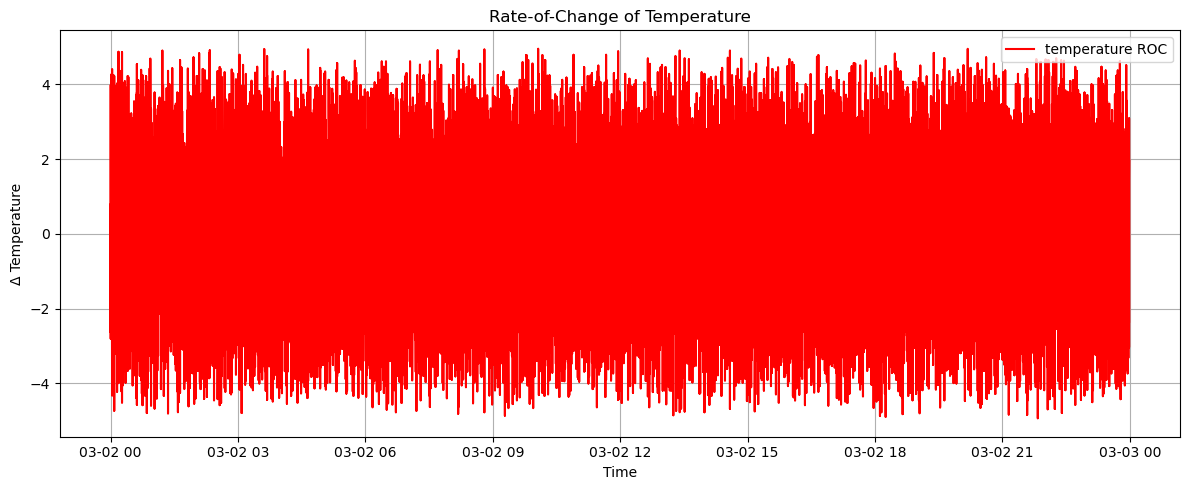

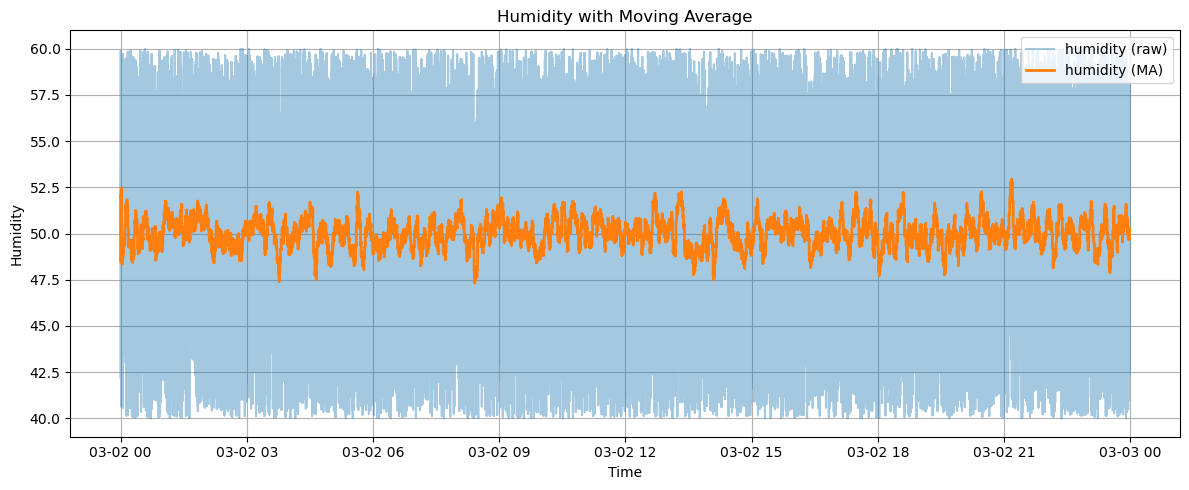

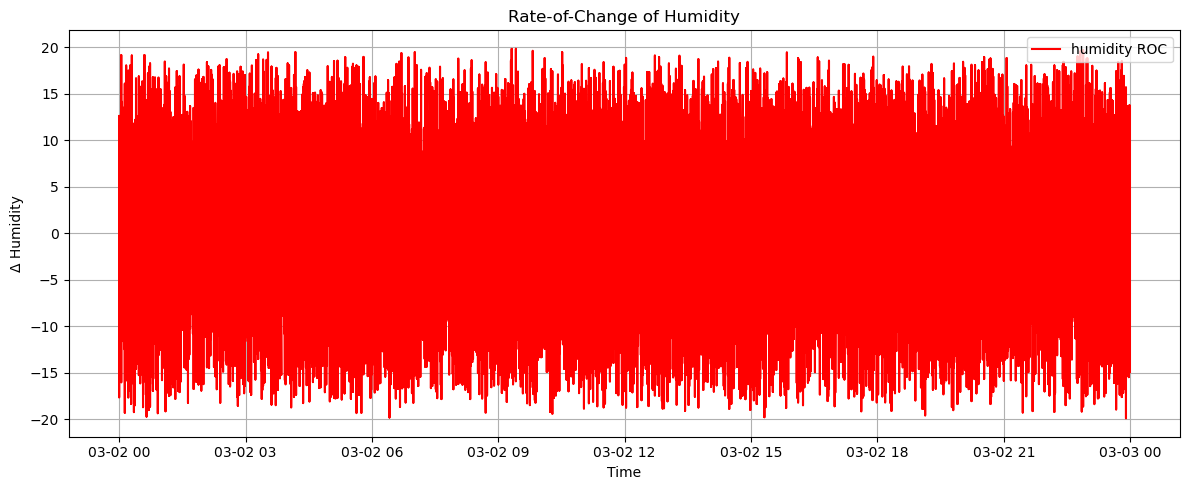

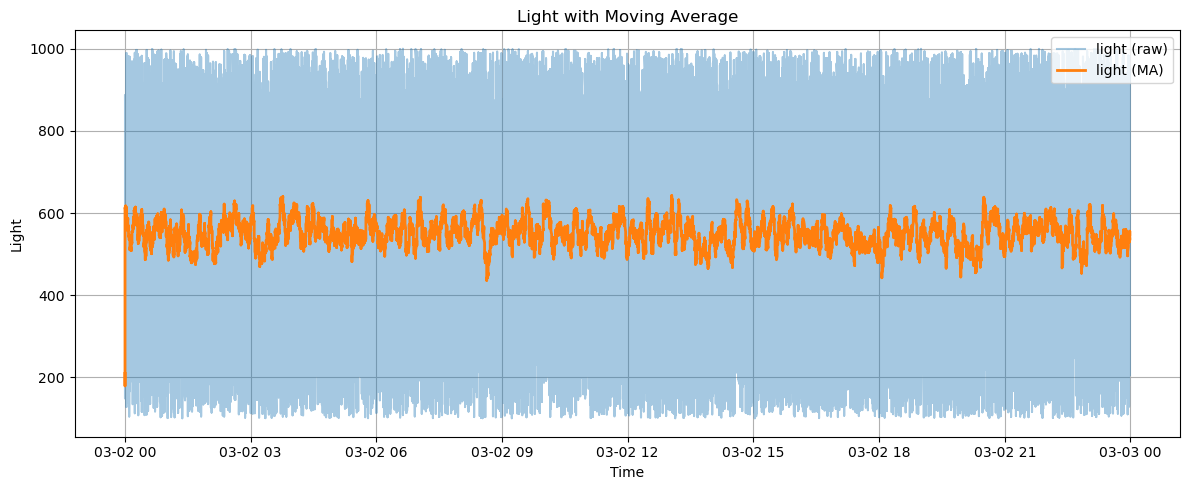

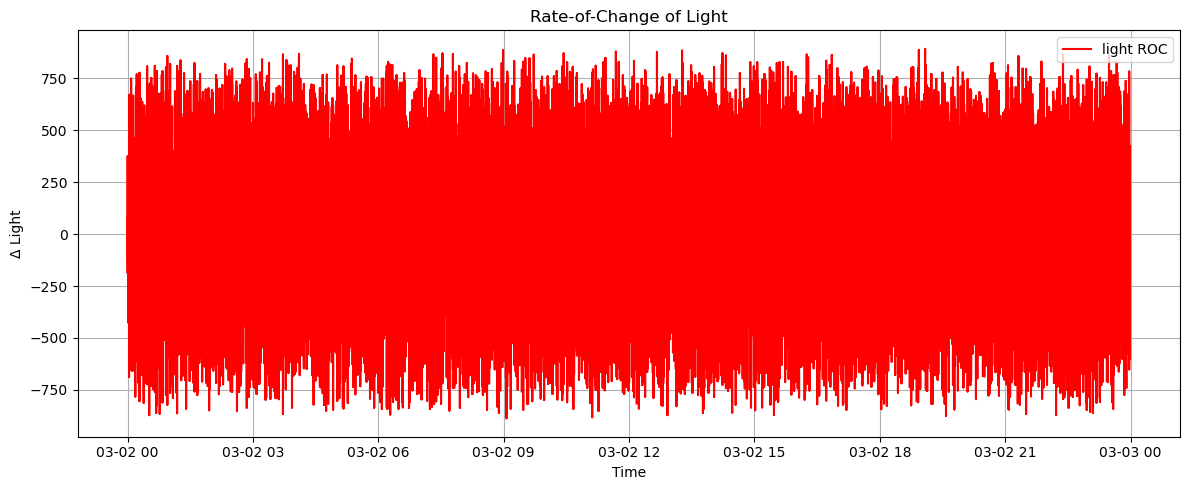

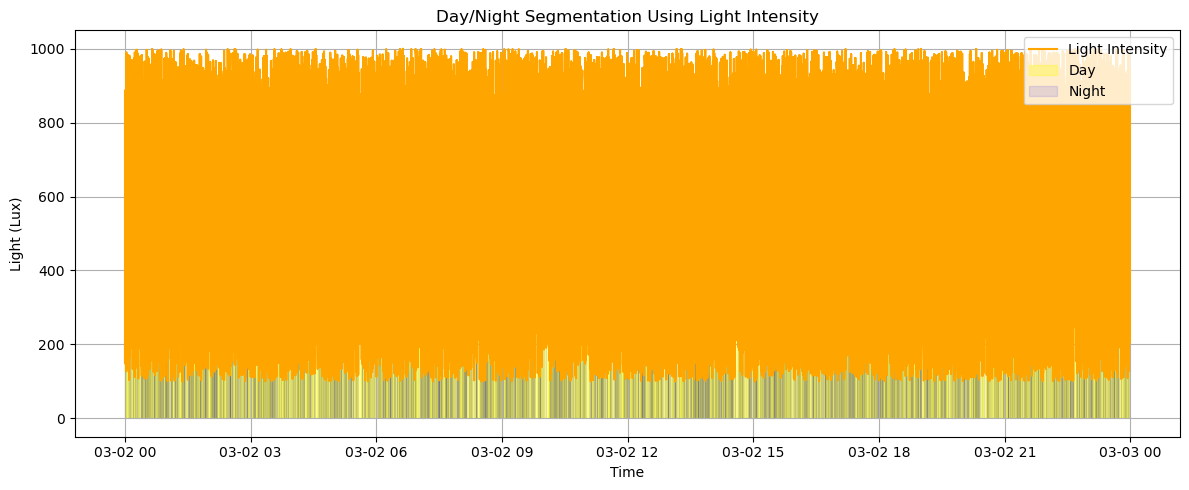

In [41]:
import pandas as pd
import matplotlib.pyplot as plt


# Load dataset

df = pd.read_csv('sensor_data_2025-03-02.csv', parse_dates=[0])  # assume first col is timestamp
time_col = df.columns[0]


# Identify sensor columns

possible_cols = ['temperature', 'humidity', 'light']
sensor_cols = [col for col in possible_cols if col in df.columns]


# Feature Engineering 

# Moving averages (window=60 → ~1 hour if data is per minute)
for col in sensor_cols:
    df[f'{col}_ma'] = df[col].rolling(window=60, min_periods=1).mean()

# Rate-of-change (difference between consecutive readings)
for col in sensor_cols:
    df[f'{col}_roc'] = df[col].diff()

# Percentage change (relative rate of change)
for col in sensor_cols:
    df[f'{col}_pct_change'] = df[col].pct_change()


# Day/Night Segmentation (if light available)

if 'light' in sensor_cols:
    DAY_THRESHOLD = 200  # lux threshold, adjust as needed
    df['cycle'] = df['light'].apply(lambda x: 'Day' if x > DAY_THRESHOLD else 'Night')


# Visualizations

for col in sensor_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df[col], alpha=0.4, label=f'{col} (raw)')
    plt.plot(df[time_col], df[f'{col}_ma'], label=f'{col} (MA)', linewidth=2)
    plt.title(f'{col.capitalize()} with Moving Average')
    plt.xlabel('Time')
    plt.ylabel(col.capitalize())
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Rate-of-change plot
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df[f'{col}_roc'], color='red', label=f'{col} ROC')
    plt.title(f'Rate-of-Change of {col.capitalize()}')
    plt.xlabel('Time')
    plt.ylabel(f'Δ {col.capitalize()}')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Day/Night visualization (if light available)

if 'light' in sensor_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df['light'], color='orange', label='Light Intensity')
    plt.fill_between(df[time_col], 0, df['light'],
                     where=df['cycle']=='Day', color='yellow', alpha=0.3, label='Day')
    plt.fill_between(df[time_col], 0, df['light'],
                     where=df['cycle']=='Night', color='blue', alpha=0.1, label='Night')
    plt.title('Day/Night Segmentation Using Light Intensity')
    plt.xlabel('Time')
    plt.ylabel('Light (Lux)')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

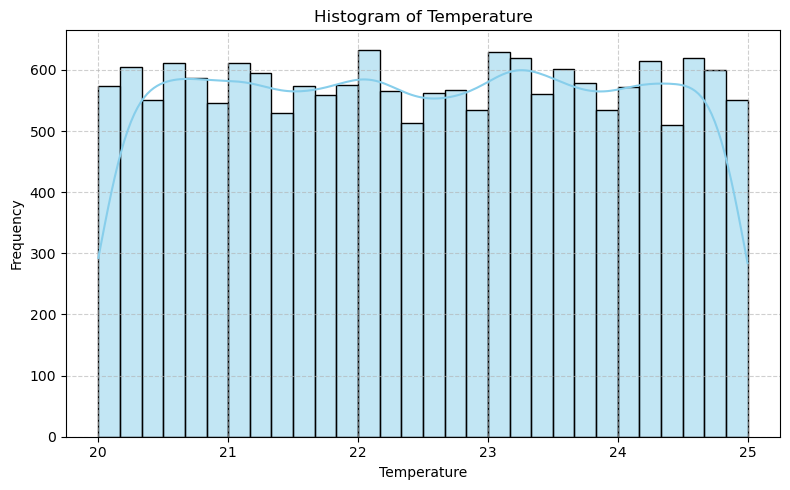

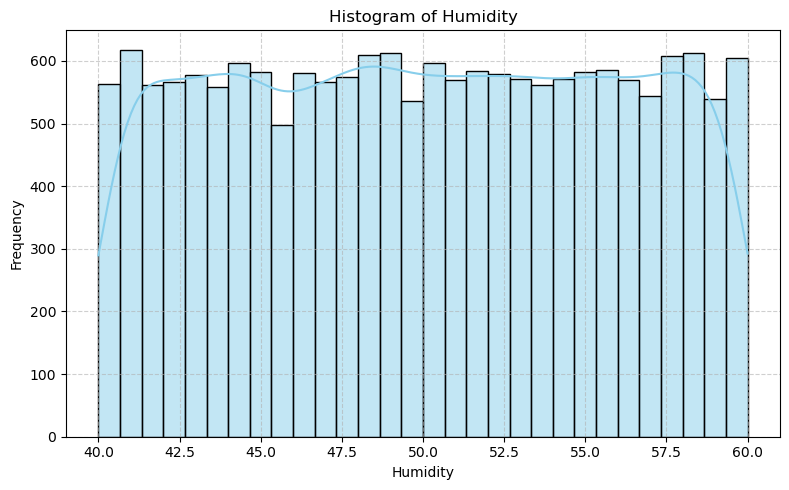

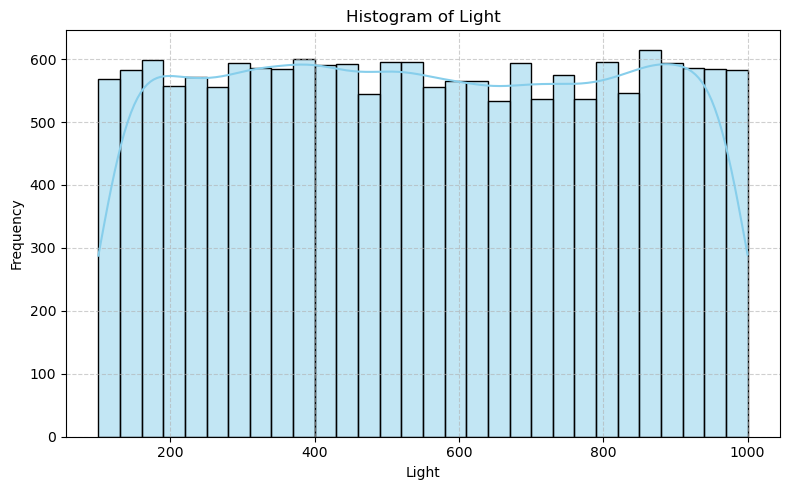

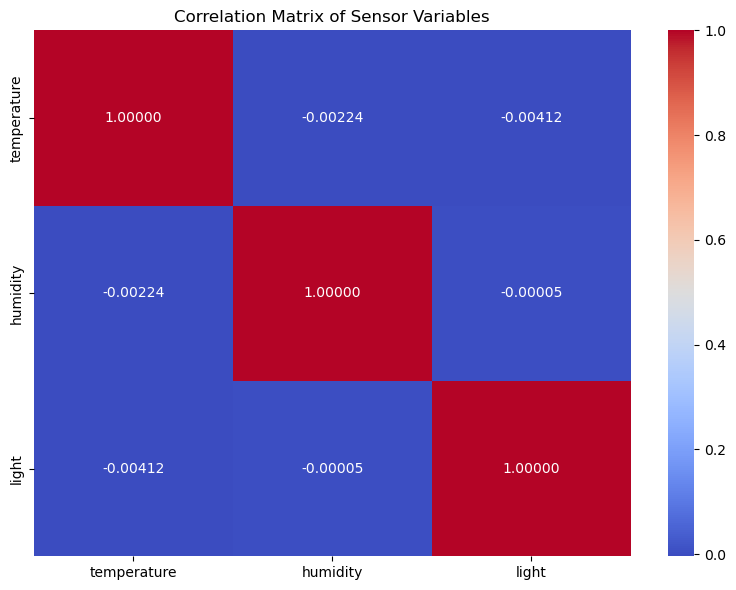

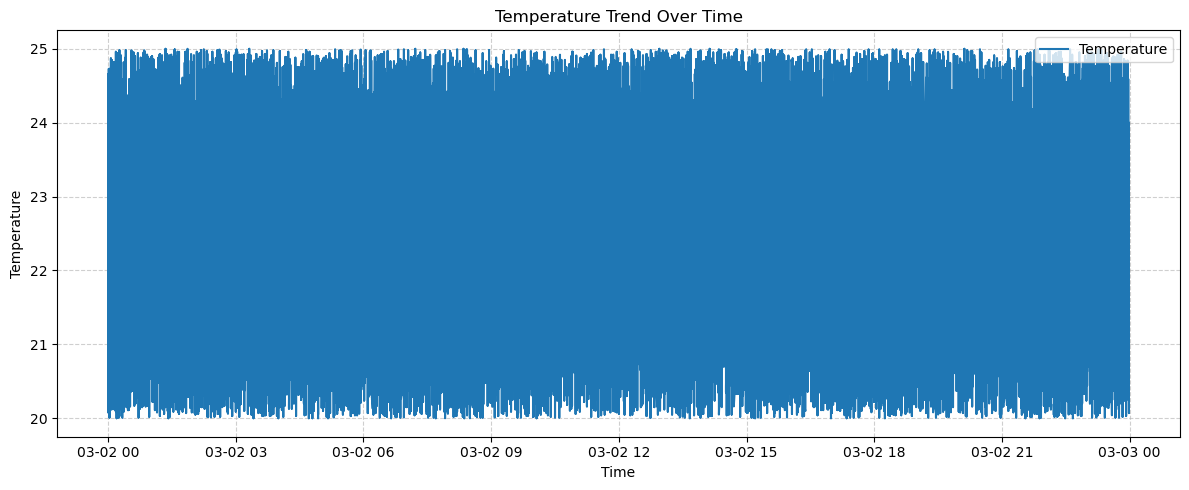

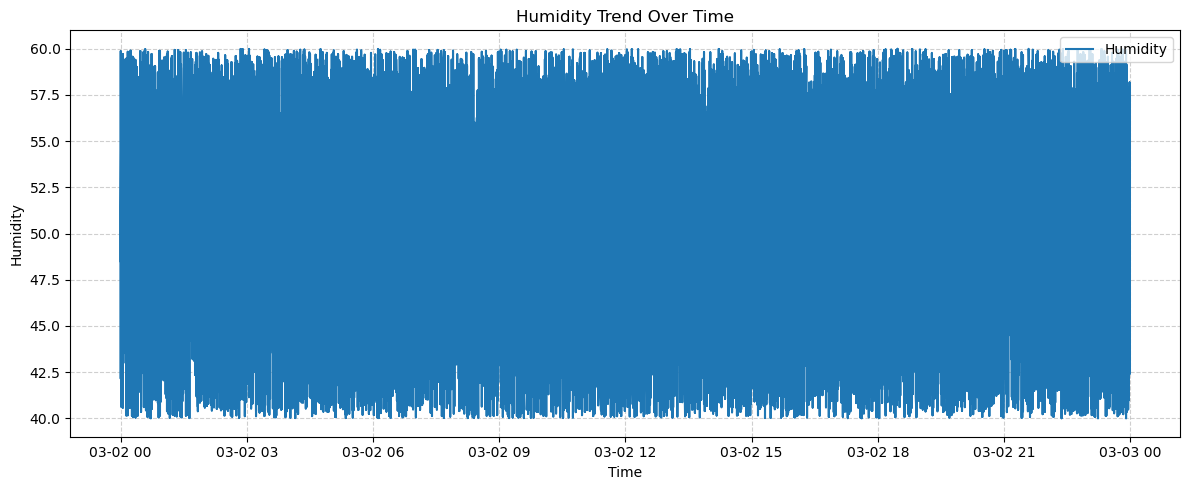

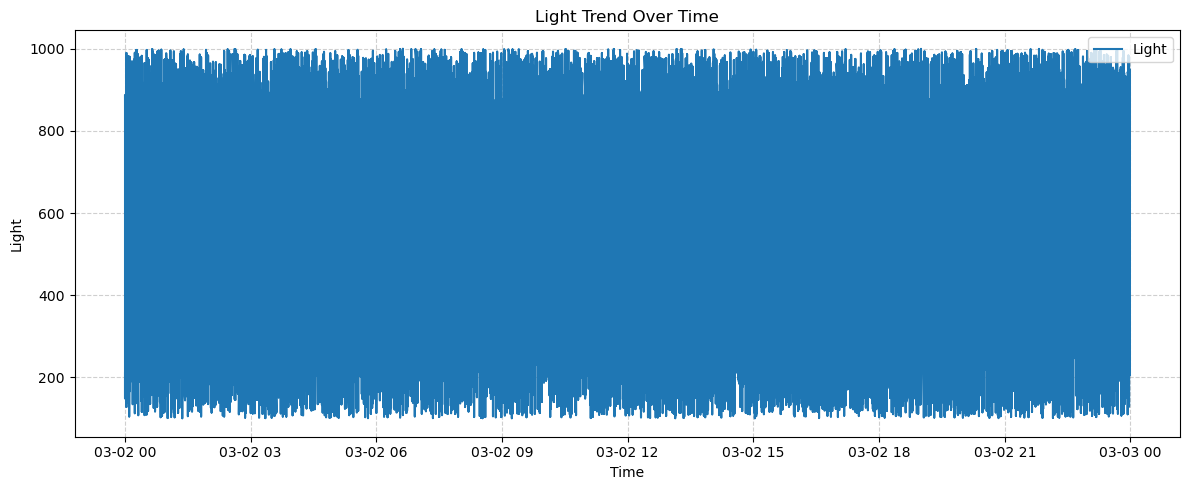

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv('sensor_data_2025-03-02.csv', parse_dates=[0])  # assume first column is timestamp
time_col = df.columns[0]

# Identify sensor columns
sensor_cols = [col for col in ['temperature', 'humidity', 'light'] if col in df.columns]


# Histograms

for col in sensor_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), bins=30, kde=True, color='skyblue')
    plt.title(f'Histogram of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Correlation Matrix Heatmap

numeric_cols = df[sensor_cols].select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".5f", cbar=True)
plt.title("Correlation Matrix of Sensor Variables")
plt.tight_layout()
plt.show()


#Trend Plots (Time Series)

for col in sensor_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df[col], label=col.capitalize(), linewidth=1.5)
    plt.title(f'{col.capitalize()} Trend Over Time')
    plt.xlabel('Time')
    plt.ylabel(col.capitalize())
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

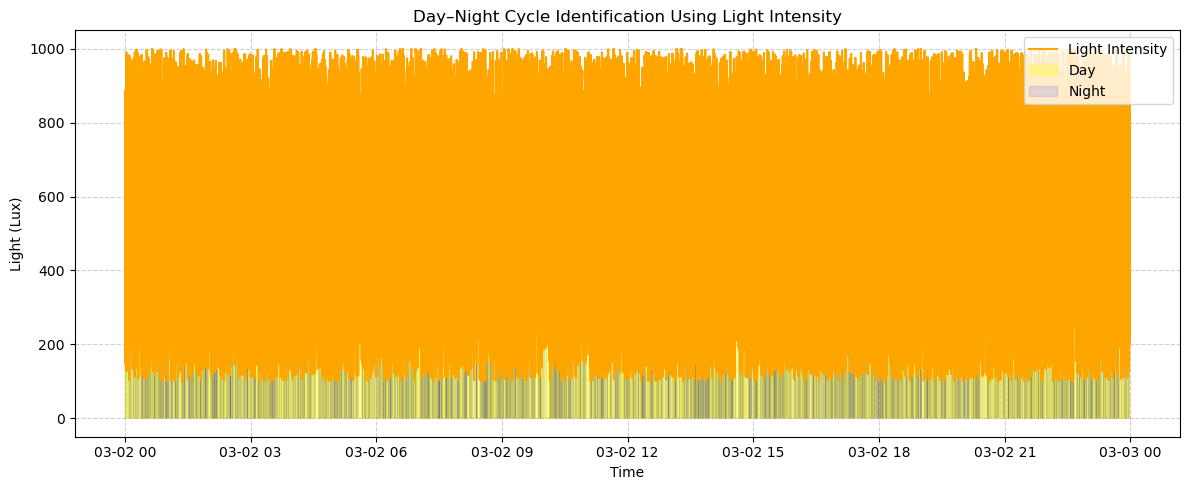

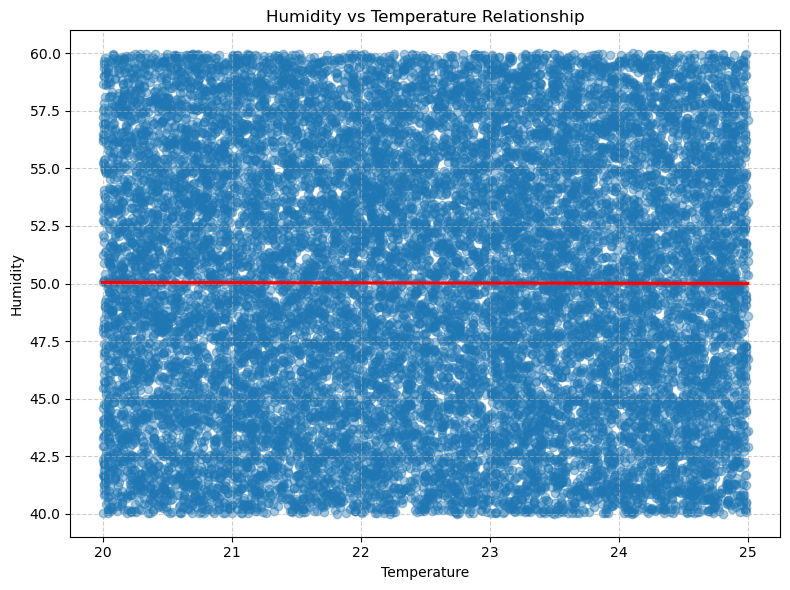

Correlation between Temperature and Humidity: -0.00


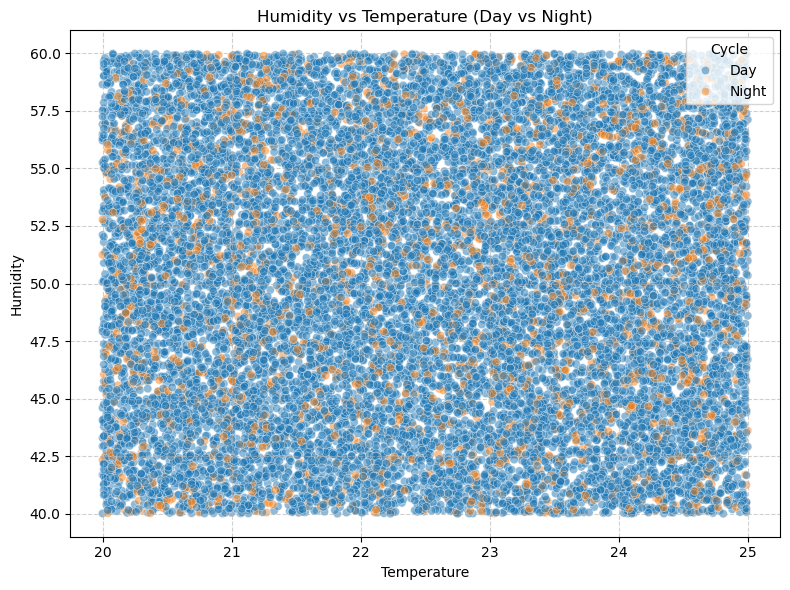

Day correlation (Temp vs Humidity): -0.00337
Night correlation (Temp vs Humidity): 0.0065


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset

df = pd.read_csv('sensor_data_2025-03-02.csv', parse_dates=[0])  # assume first column is timestamp
time_col = df.columns[0]

# Identify sensor columns
sensor_cols = [col for col in ['temperature', 'humidity', 'light'] if col in df.columns]


# Day–Night Cycle Identification

if 'light' in sensor_cols:
    DAY_THRESHOLD = 200  # lux threshold (adjust if needed)
    df['cycle'] = df['light'].apply(lambda x: 'Day' if x > DAY_THRESHOLD else 'Night')

    # Plot light intensity with day/night shading
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df['light'], color='orange', label='Light Intensity')
    plt.fill_between(df[time_col], 0, df['light'],
                     where=df['cycle']=='Day', color='yellow', alpha=0.3, label='Day')
    plt.fill_between(df[time_col], 0, df['light'],
                     where=df['cycle']=='Night', color='blue', alpha=0.1, label='Night')
    plt.title('Day–Night Cycle Identification Using Light Intensity')
    plt.xlabel('Time')
    plt.ylabel('Light (Lux)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


#Humidity–Temperature Relationship

if 'temperature' in sensor_cols and 'humidity' in sensor_cols:
    # Scatter plot with regression line
    plt.figure(figsize=(8, 6))
    sns.regplot(x=df['temperature'], y=df['humidity'], scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    plt.title('Humidity vs Temperature Relationship')
    plt.xlabel('Temperature')
    plt.ylabel('Humidity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Correlation coefficient
    corr_value = df[['temperature', 'humidity']].corr().iloc[0,1]
    print(f"Correlation between Temperature and Humidity: {corr_value:.2f}")

    # Segmented analysis: Day vs Night
    if 'cycle' in df.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=df, x='temperature', y='humidity', hue='cycle', alpha=0.5)
        plt.title('Humidity vs Temperature (Day vs Night)')
        plt.xlabel('Temperature')
        plt.ylabel('Humidity')
        plt.legend(title='Cycle')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # Grouped correlation
        day_corr = df[df['cycle']=='Day'][['temperature','humidity']].corr().iloc[0,1]
        night_corr = df[df['cycle']=='Night'][['temperature','humidity']].corr().iloc[0,1]
        print(f"Day correlation (Temp vs Humidity): {day_corr:.5f}")
        print(f"Night correlation (Temp vs Humidity): {night_corr:.4f}")

Basic Statistical Summaries:
       temperature   humidity         light
mean    22.495532  50.021796    549.752845
min     20.000000  40.000000    100.000000
max     25.000000  60.000000    999.990000
var      2.091291  33.437511  67861.497446


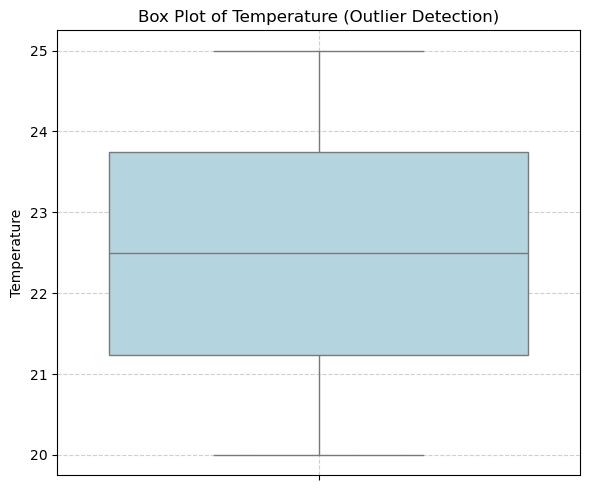

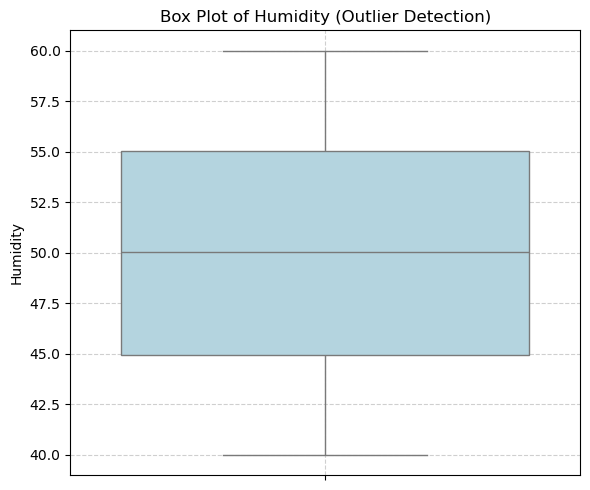

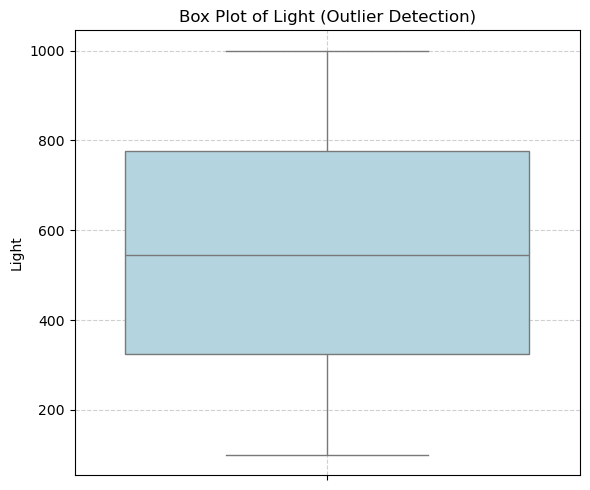

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset

df = pd.read_csv('sensor_data_2025-03-02.csv', parse_dates=[0])  # assume first column is timestamp
time_col = df.columns[0]

# Identify sensor columns
sensor_cols = [col for col in ['temperature', 'humidity', 'light'] if col in df.columns]


#Basic Statistical Summaries

stats_summary = df[sensor_cols].agg(['mean', 'min', 'max', 'var'])
print("Basic Statistical Summaries:\n", stats_summary)


#Box Plots for Outlier Detection

for col in sensor_cols:
    plt.figure(figsize=(6, 5))
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Box Plot of {col.capitalize()} (Outlier Detection)')
    plt.ylabel(col.capitalize())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

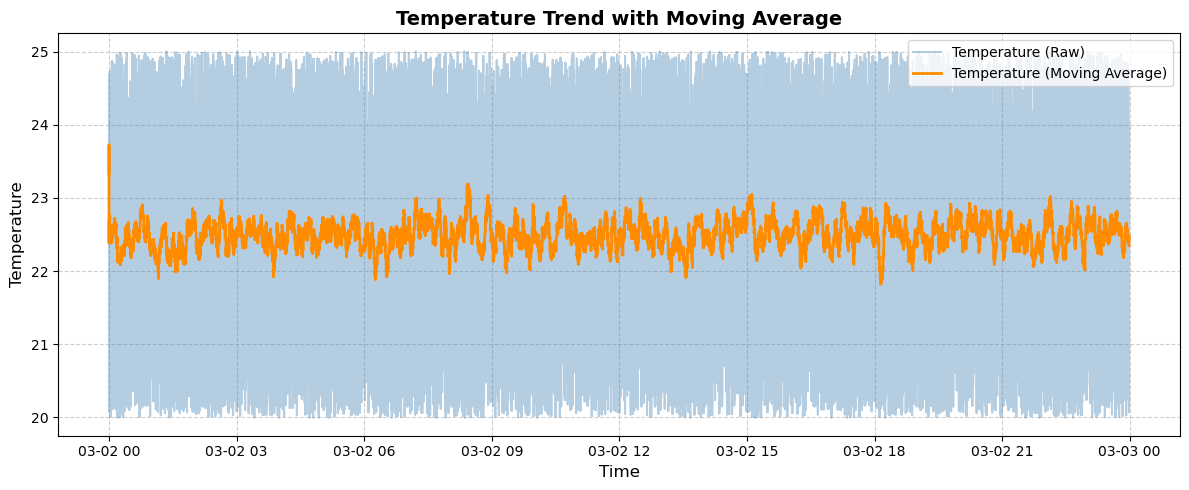

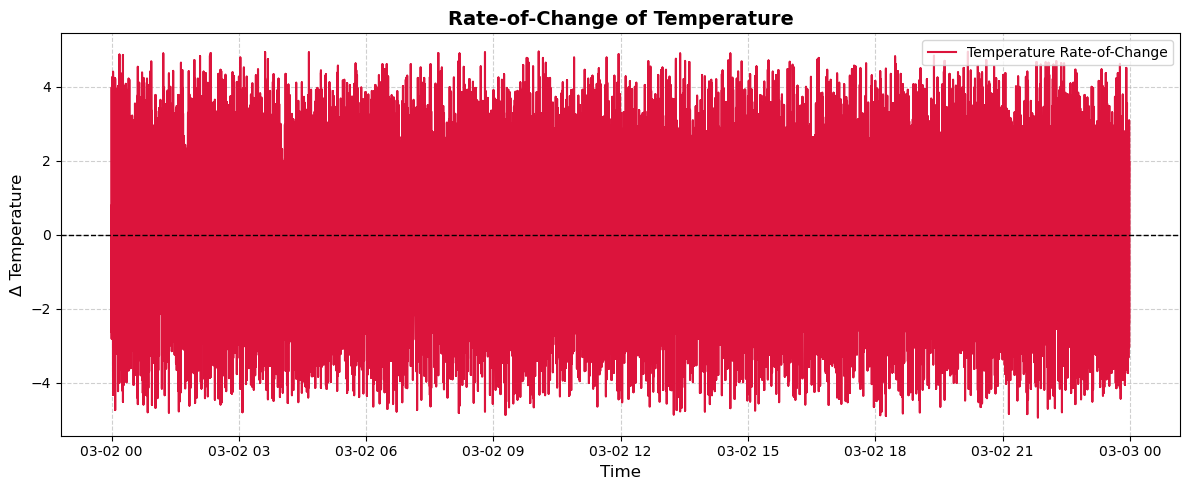

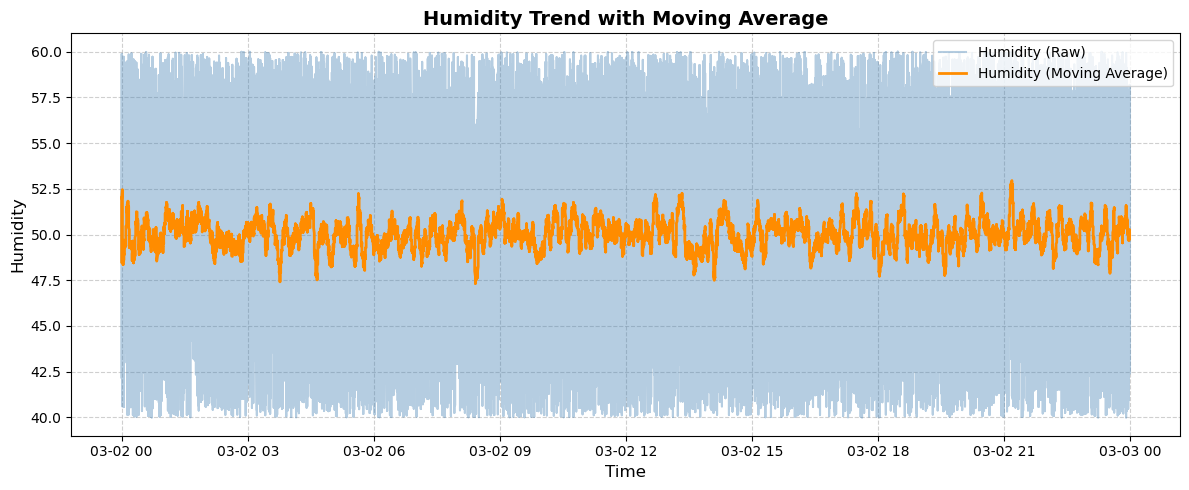

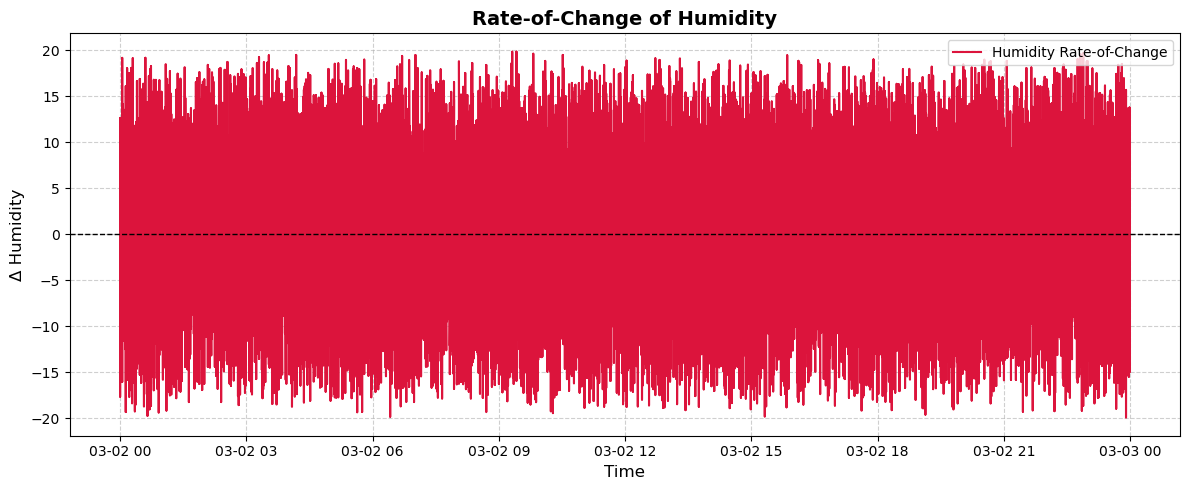

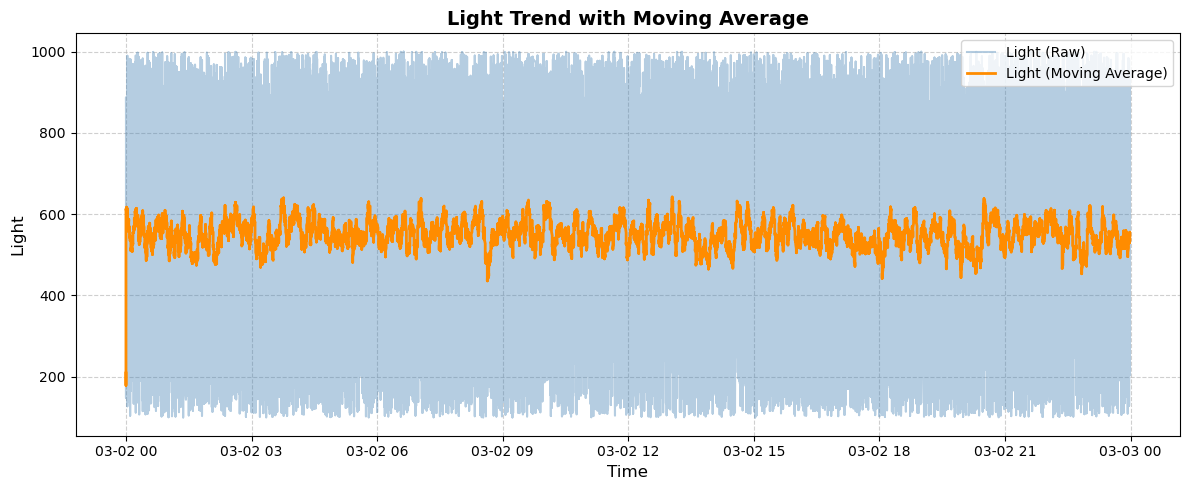

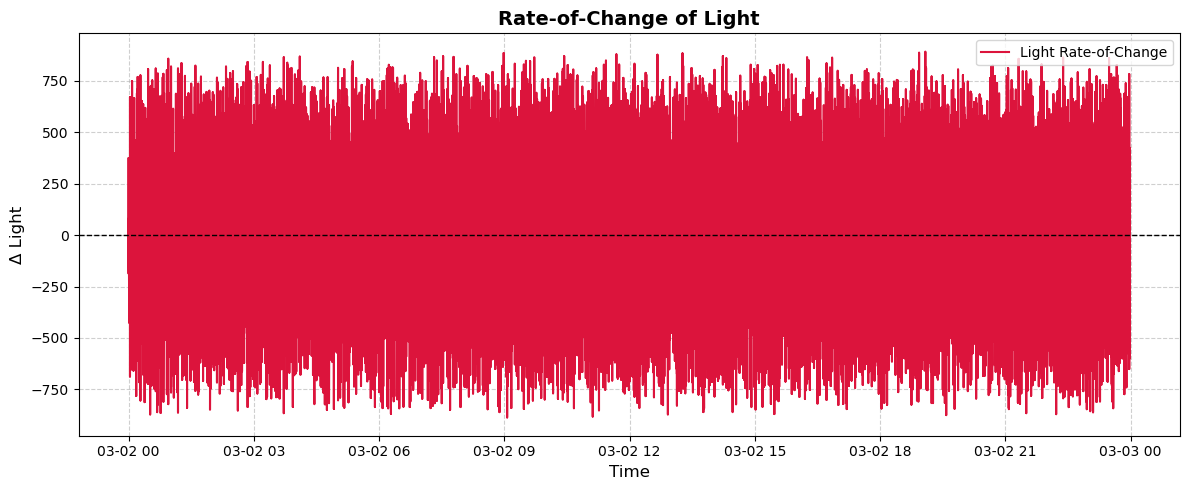

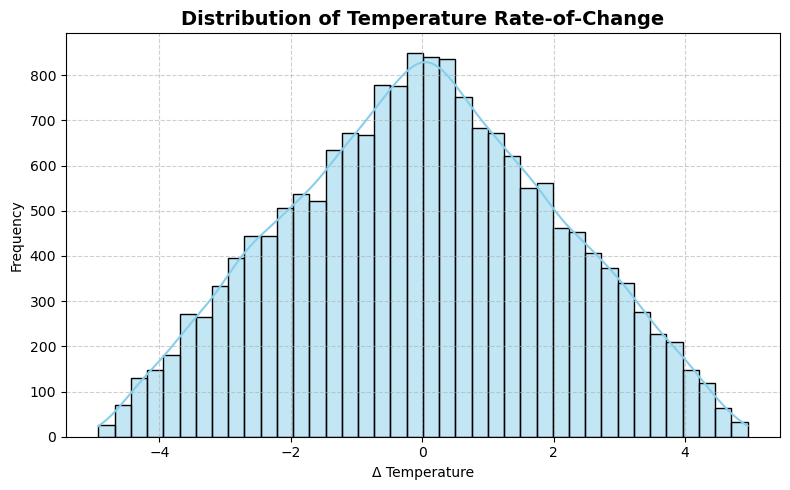

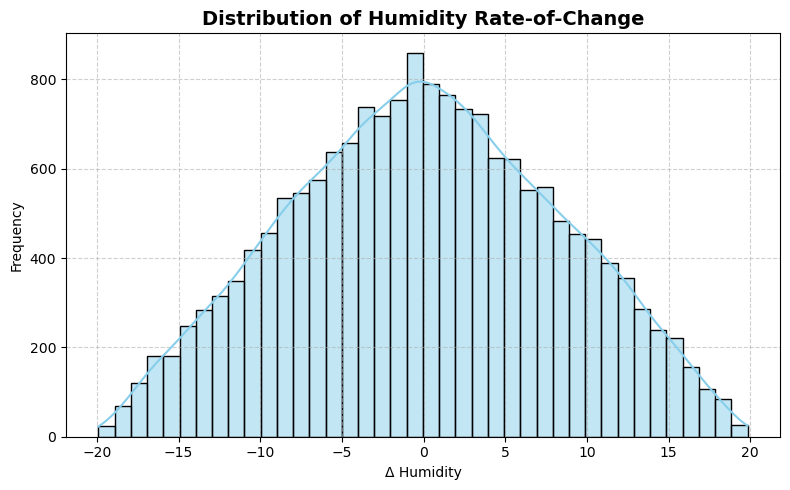

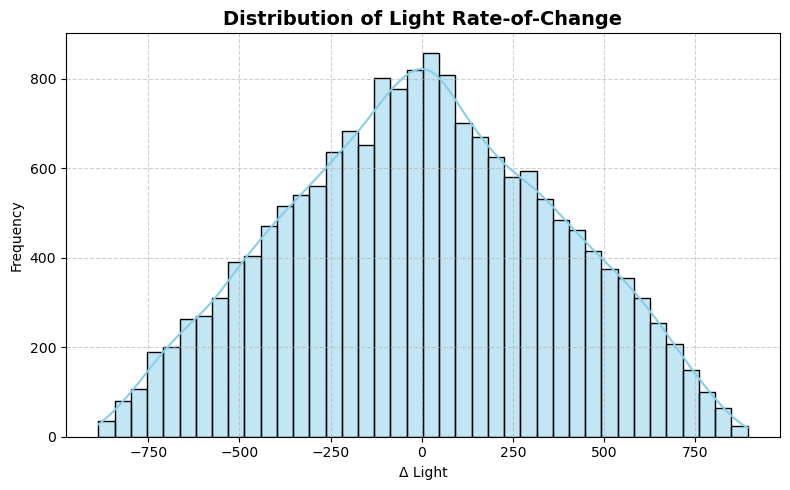

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset

df = pd.read_csv('sensor_data_2025-03-02.csv', parse_dates=[0])  # assume first column is timestamp
time_col = df.columns[0]

# Identify sensor columns
sensor_cols = [col for col in ['temperature', 'humidity', 'light'] if col in df.columns]

# Moving averages (window=60 → ~1 hour if data is per minute)
for col in sensor_cols:
    df[f'{col}_ma'] = df[col].rolling(window=60, min_periods=1).mean()

# Rate-of-change (difference between consecutive readings)
for col in sensor_cols:
    df[f'{col}_roc'] = df[col].diff()


# Technical Plots
for col in sensor_cols:
    # Plot raw data + moving average
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df[col], alpha=0.4, label=f'{col.capitalize()} (Raw)', color='steelblue')
    plt.plot(df[time_col], df[f'{col}_ma'], label=f'{col.capitalize()} (Moving Average)', color='darkorange', linewidth=2)
    plt.title(f'{col.capitalize()} Trend with Moving Average', fontsize=14, fontweight='bold')
    plt.xlabel('Time', fontsize=12)
    plt.ylabel(col.capitalize(), fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Plot rate-of-change
    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df[f'{col}_roc'], color='crimson', label=f'{col.capitalize()} Rate-of-Change')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'Rate-of-Change of {col.capitalize()}', fontsize=14, fontweight='bold')
    plt.xlabel('Time', fontsize=12)
    plt.ylabel(f'Δ {col.capitalize()}', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# Distribution of ROC values

for col in sensor_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[f'{col}_roc'].dropna(), bins=40, kde=True, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()} Rate-of-Change', fontsize=14, fontweight='bold')
    plt.xlabel(f'Δ {col.capitalize()}')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Light Threshold Used: 545.85
    light day_night
0  209.27     Night
1  148.53     Night
2  523.69     Night
3  488.67     Night
4  588.76       Day


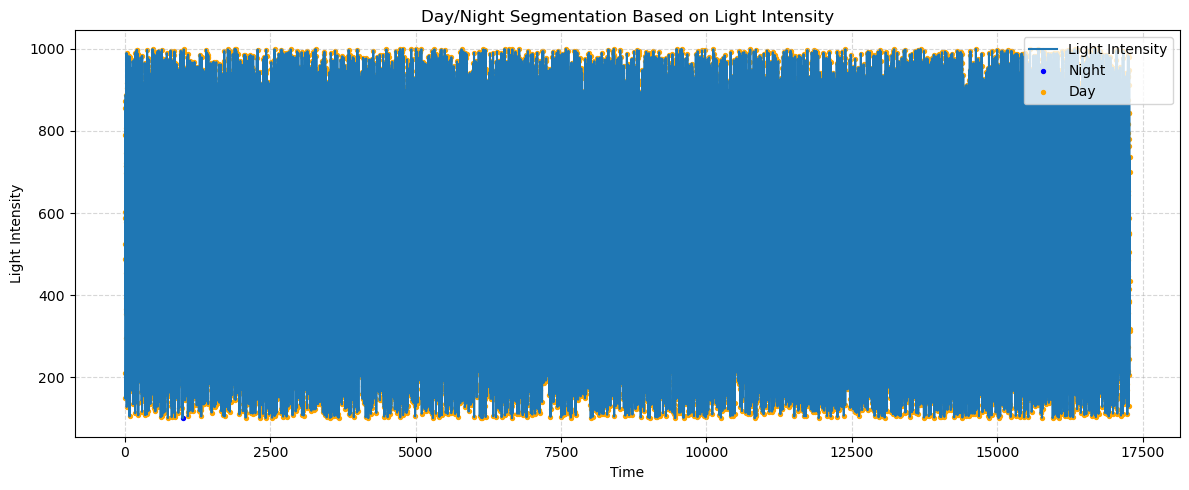

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 5))

# df must already be loaded
# df contains: timestamp, temperature, humidity, light

# Auto threshold using median
light_threshold = df['light'].median()

# Create day/night label
df['day_night'] = df['light'].apply(lambda x: 'Day' if x > light_threshold else 'Night')

print("Light Threshold Used:", light_threshold)
print(df[['light', 'day_night']].head())
light_threshold = 100  # change if needed

df['day_night'] = df['light'].apply(lambda x: 'Day' if x > light_threshold else 'Night')


plt.plot(df.index, df['light'], label='Light Intensity')

# Shade night regions
night = df[df['day_night'] == 'Night']['light']
plt.scatter(night.index, night, color='blue', label='Night', s=8)

# Shade day regions
day = df[df['day_night'] == 'Day']['light']
plt.scatter(day.index, day, color='orange', label='Day', s=8)

plt.title("Day/Night Segmentation Based on Light Intensity")
plt.xlabel("Time")
plt.ylabel("Light Intensity")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
